In [1]:
import numpy as np
import skimage.io as io
import skimage.transform as tf
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, interp1d
from matplotlib.colors import Normalize

In [2]:
# Affiche un pixel dans les 3 dimensions
def display_pixel(ax, x, y, z, color="r", line=False, linecolor="k"):
    x, y = x+.5, y+.5
    if line:
        ax.plot([x, x], [y, y], [0, z], color=linecolor, zorder=4)
    ax.plot(x, y, z, marker='o', ms=10, mec=linecolor, mfc=color, zorder=4)

In [3]:
# Fonction principale
def main(img, xy_interp, kind, filename):
    
    # Couleurs des interpolations
    clr1 = (.6,0,.6)
    clr2 = (1,0,0)
    
    # Coordonnées de l'interpolation
    xi, yi = xy_interp
    
    # Image
    N = img.shape[0]
    
    # Nombre d'échantillons dans les interpolations
    M = 100
    m = np.linspace(0, N-1, M)
    
    # Initialisation de la figure
    ax = plt.figure(figsize=(8,8)).add_subplot(projection='3d')
    
    # Affichage de l'image
    norm = Normalize()
    colors = plt.get_cmap("gray")(norm(img))
    yy, xx = np.mgrid[0:N+1, 0:N+1]
    zz = np.full_like(xx, 0)
    ax.plot_surface(xx, yy, zz, rstride=1, cstride=1, facecolors=colors, shade=False, zorder=1)
    
    # Affichage des pixels de l'image
    for x in range(N):
        for y in range(N):
            z = img[y,x]
            display_pixel(ax, x, y, z, color=[z/N]*3, line=True, linecolor=(.5,.5,.5))
    
    # Interpolations dans la première dimension
    w = np.array([])
    for y in range(N):
    
        # Calcul de l'interpolation
        f = interp1d(range(N), img[y,:], kind=kind)
    
        # Affichage de la courbe interpolée
        ax.plot(m+.5, np.ones(M)*y+.5, f(m), color=clr1, zorder=3)
    
        # Affichage du pixel que l'on conserve
        display_pixel(ax, xi, y, f(xi), color=clr1, linecolor=clr1)
    
        # Enregistrement de cette valeur pour la suite
        w = np.append(w, f(xi))
    
    # Interpolation dans la seconde dimension
    f = interp1d(range(N), w, kind=kind)
    
    # Affichage de la courbe interpolée
    ax.plot(np.ones(M)*xi+.5, m+.5, f(m), color=clr2, zorder=3)
    
    # Affichage du pixel final
    display_pixel(ax, xi, yi, f(yi), color=clr2, line=True, linecolor=clr2)
    
    # Finalisation de la figure
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

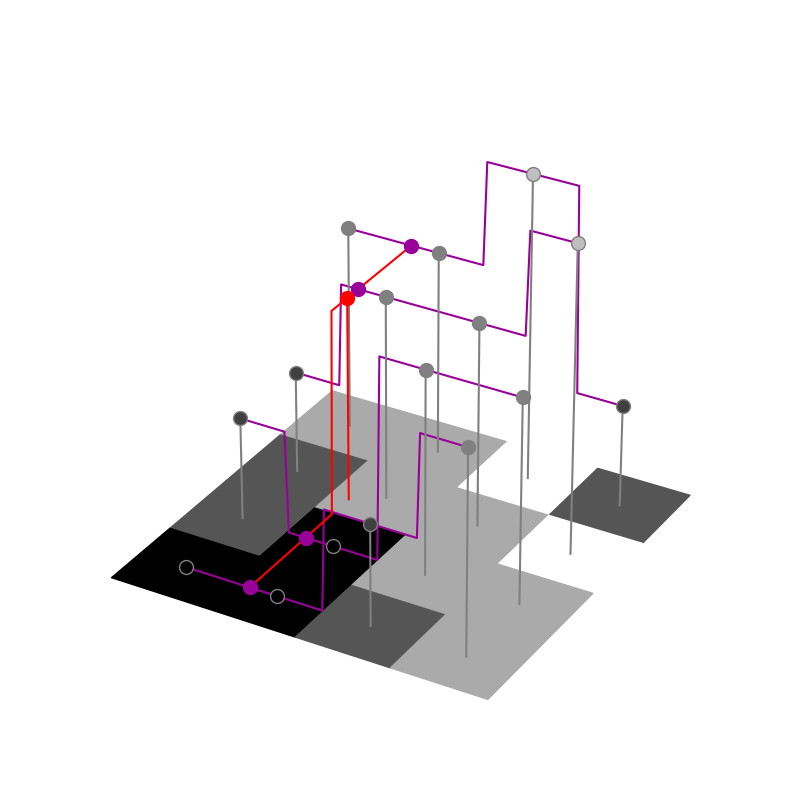

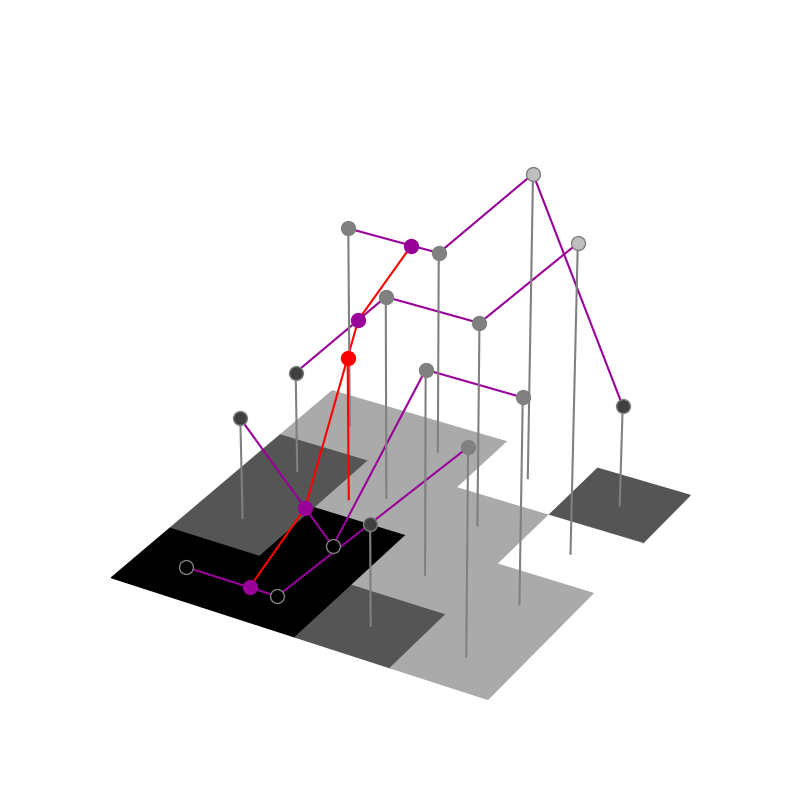

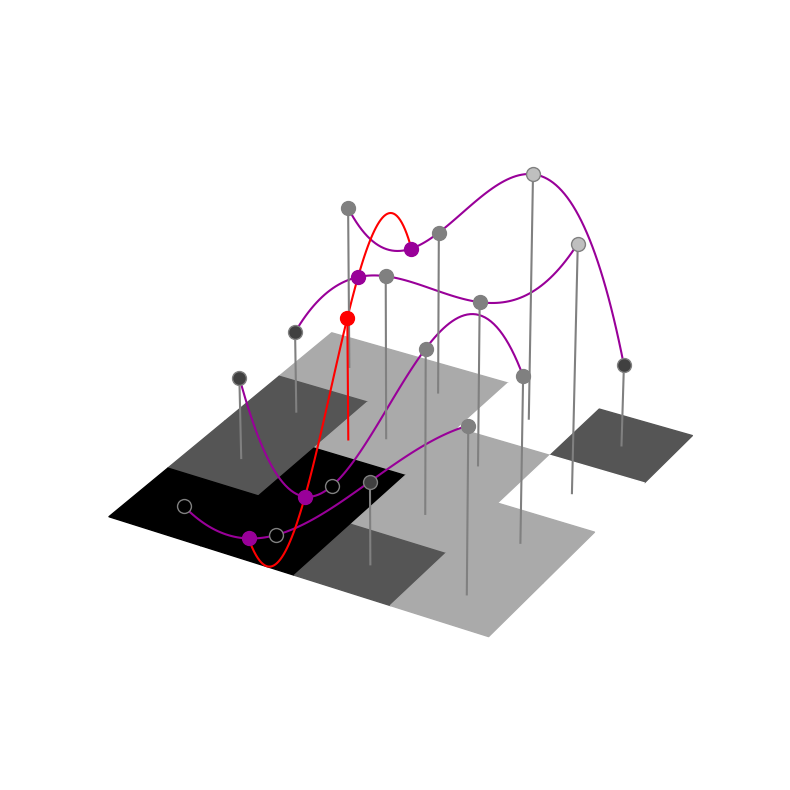

In [4]:
img = np.array([ [0,0,1,2], [1,0,2,2], [1,2,2,3], [2,2,3,1] ])
xi, yi = .7, 1.8
for kind in ["nearest", "linear", "cubic"]:
    main(img, (xi,yi), kind, f"interp-{kind}-3d.svg")

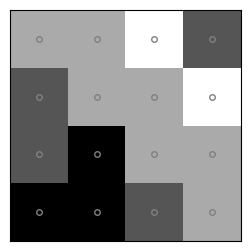

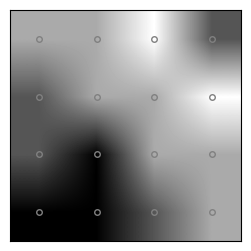

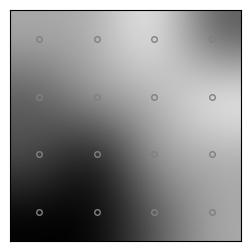

In [11]:
kind = ["nearest", "bilinear", "bicubic"]

N = len(img)
n = np.arange(N)
mesh = np.meshgrid(n,n)

for kind in methods:

    fig, ax = plt.subplots(1, 1, figsize=(5,3))

    ax.imshow(img, interpolation=kind, cmap="gray", vmin=0, vmax=3)
    ax.plot(mesh[0], mesh[1], marker='o', ms=4, lw=0, markeredgecolor='gray', color="#0000")
    # plt.scatter(x.ravel(), y.ravel(), c=colors, cmap='gray', vmin=0, vmax=3, s=20, edgecolors='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.invert_yaxis()

    plt.savefig(f"interp-{kind}-2d.svg", bbox_inches='tight')